In [ ]:
import pandas as pd
df=pd.read_csv("EastWestAirlines (1).csv",index_col=1)
df

,ID#,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Balance,,,,,,,,,,,
28143,1,0,1,1,1,174,1,0,0,7000,0
19244,2,0,1,1,1,215,2,0,0,6968,0
41354,3,0,1,1,1,4123,4,0,0,7034,0
14776,4,0,1,1,1,500,1,0,0,6952,0
97752,5,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...
18476,4017,0,1,1,1,8525,4,200,1,1403,1
64385,4018,0,1,1,1,981,5,0,0,1395,1
73597,4019,0,3,1,1,25447,8,0,0,1402,1


In [ ]:
df=df.drop(columns=['ID#'])
df

,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Balance,,,,,,,,,,
28143,0,1,1,1,174,1,0,0,7000,0
19244,0,1,1,1,215,2,0,0,6968,0
41354,0,1,1,1,4123,4,0,0,7034,0
14776,0,1,1,1,500,1,0,0,6952,0
97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...
18476,0,1,1,1,8525,4,200,1,1403,1
64385,0,1,1,1,981,5,0,0,1395,1
73597,0,3,1,1,25447,8,0,0,1402,1


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 3999 entries, 28143 to 3016
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Qual_miles         3999 non-null   int64
 1   cc1_miles          3999 non-null   int64
 2   cc2_miles          3999 non-null   int64
 3   cc3_miles          3999 non-null   int64
 4   Bonus_miles        3999 non-null   int64
 5   Bonus_trans        3999 non-null   int64
 6   Flight_miles_12mo  3999 non-null   int64
 7   Flight_trans_12    3999 non-null   int64
 8   Days_since_enroll  3999 non-null   int64
 9   Award?             3999 non-null   int64
dtypes: int64(10)
memory usage: 343.7 KB


,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [ ]:
X=df.iloc[:,0:]
X

,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Balance,,,,,,,,,,
28143,0,1,1,1,174,1,0,0,7000,0
19244,0,1,1,1,215,2,0,0,6968,0
41354,0,1,1,1,4123,4,0,0,7034,0
14776,0,1,1,1,500,1,0,0,6952,0
97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...
18476,0,1,1,1,8525,4,200,1,1403,1
64385,0,1,1,1,981,5,0,0,1395,1
73597,0,3,1,1,25447,8,0,0,1402,1


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
linkage_matrix = linkage(df, method='ward')


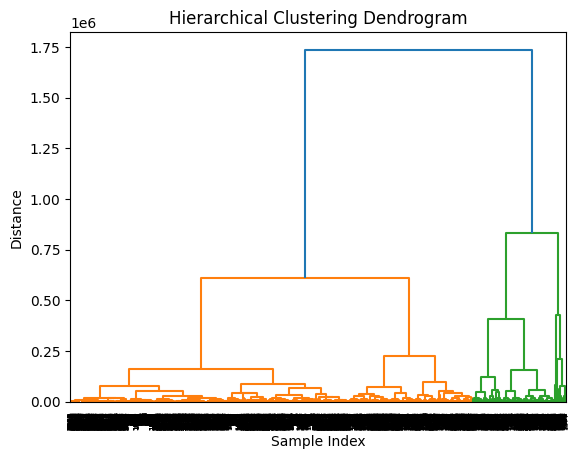

In [ ]:
# Plot the dendrogram
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, n_init=30, random_state=0)
kmeans.fit(X)
Y = kmeans.predict(X)
cluster_counts = pd.DataFrame(Y, columns=['Cluster']).value_counts().reset_index(name='Count')
print(cluster_counts)
print("Inertia:", kmeans.inertia_)


   Cluster  Count
0        0   2315
1        2    908
2        4    501
3        1    245
4        3     30
Inertia: 202848432277.7466


In [ ]:
# Elbow Method
inertia = []
for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=0)
    km.fit(X)
    inertia.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

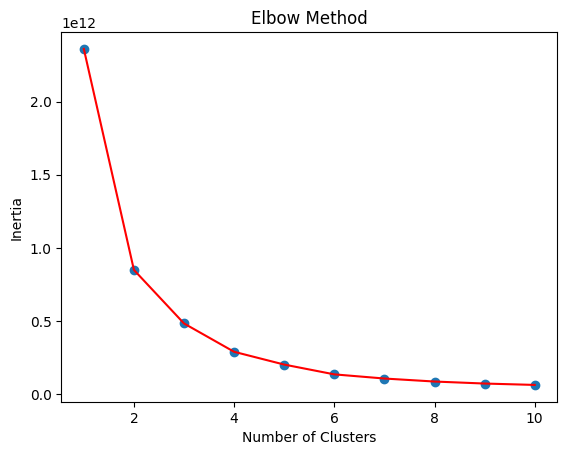

In [ ]:
# Plotting the Elbow Method
plt.scatter(range(1, 11), inertia)
plt.plot(range(1, 11), inertia, color='red')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_X = SS.fit_transform(X)

In [ ]:
from sklearn.cluster import DBSCAN, KMeans
dbscan = DBSCAN(eps=1.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(SS_X)

cl = pd.DataFrame(dbscan_labels, columns=['cluster'])
print(cl['cluster'].value_counts())

 0    2441
 1    1315
-1     189
 6      15
 5       9
 3       8
 2       7
 4       5
 9       4
 7       3
 8       3
Name: cluster, dtype: int64


In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
cl.reset_index(drop=True, inplace=True)

In [ ]:
clustered_data = pd.concat([df, cl], axis=1)


In [ ]:
final_data = clustered_data[clustered_data['cluster'] != -1]

In [ ]:
kmeans = KMeans(n_clusters=5, n_init=30, random_state=0)
kmeans_labels = kmeans.fit_predict(final_data)

In [ ]:
kmeans_cluster_counts = pd.DataFrame(kmeans_labels, columns=['cluster']).value_counts().reset_index(name='Count')
print(kmeans_cluster_counts)

In [ ]:
# Elbow Method for KMeans
inertia = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=0)
    km.fit(final_data.drop('cluster', axis=1))  # Drop the 'cluster' column before fitting
    inertia.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

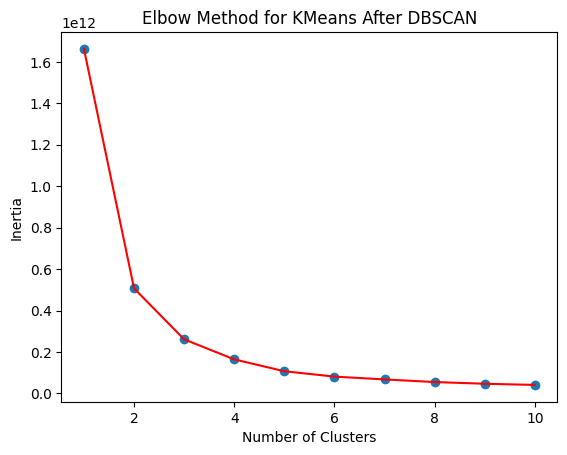

In [ ]:

# Plotting the Elbow Method
plt.scatter(range(1, 11), inertia)
plt.plot(range(1, 11), inertia, color='red')
plt.title('Elbow Method for KMeans After DBSCAN')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()